[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/statistical_analysis/a_b_testing/bayesian)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/statistical_analysis/a_b_Testing/bayesian/bayesian_testing_portfolio.ipynb)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/AB%20Testing%20Bayesian.png)

# Setup

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Setup.png)

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom
import arviz as az

# Test Design

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Test%20Design.png)

## Sample Size

Power calculation requires both:

*   The posterior probability that (B > A) exceeds the threshold (e.g., 95%)
*   The entire 95% HDI of the lift is above 0

Reflects the chance the experiment will yield a result with a difference that is both statistically confident and positive.

(Power = fraction of simulated experiments where you confidently conclude B > A and the credible effect size exceeds 0)

Function:

In [68]:
import arviz as az
import numpy as np

def bayesian_power_simulation(
    alpha_A, beta_A,  # prior for A (successes/failures)
    alpha_B, beta_B,  # prior for B (successes/failures)
    true_rate_A,      # assumed true conversion rate for A (ground truth)
    true_rate_B,      # assumed true conversion rate for B (ground truth + mde)
    n_per_group_start,# starting sample size (per group)
    n_per_group_end,  # max sample size to test
    threshold=0.95,   # posterior probability threshold for decision to declare B better
    power_target=0.8, # desired power/assurance
    step=1000,        # increment sample size step
    simulations=5000,  # number of simulated experiments per sample size
    min_detectable_lift=0.01  # minimum detectable lift (absolute difference in rates)
):
    n = n_per_group_start
    # Loop through n
    while n <= n_per_group_end:
    # Simulate data (# of successes for each simulation) from binomial distribution based on ground truth rates
        # Experiment size is n and it is run __ # of simulations times
        # n is # of trials, successes are out of n
        success_A = np.random.binomial(n, true_rate_A, size=simulations)
        success_B = np.random.binomial(n, true_rate_B, size=simulations)

        # Add simulated data to priors to get posteriors:
        # Posterior parameters = prior + data
          # Each are of length: # of simulations
          # Represent updated belief after seeing data
        post_alpha_A = alpha_A + success_A
        post_beta_A = beta_A + n - success_A
        post_alpha_B = alpha_B + success_B
        post_beta_B = beta_B + n - success_B

        passes = 0  # count simulations meeting criteria

        # Simulate posterior probabilities from beta distribution and calculate P(p_B > p_A)
          # Loop through # of simulations in the form of the posteriors
          # samples_A and samples_B are arrays of length 1000 (posterior samples for one simulated experiment)
          # samples_B > samples_A produces a boolean array of length 1000 (True where B > A, False otherwise)

        for a, b, c, d in zip(post_alpha_A, post_beta_A, post_alpha_B, post_beta_B):
          # Samples A and B are probabilities based on the beta distributions for A and B
            samples_A = np.random.beta(a, b, size=1000)
            samples_B = np.random.beta(c, d, size=1000)

            # Compares: samples_B[0] vs. samples_A[0] etc.
            #    # True = 1, False = 0
            #    # mean = (1 + 0 + 1 + 1) / 4 = 0.75
            # prob = posterior probability p_B > p_A
            # p_B > p_A for one simulation
            prob = np.mean(samples_B > samples_A)

            # Lift samples: B - A
            lift_samples = samples_B - samples_A

            # HDI bounds of lift
            hdi_bounds = az.hdi(lift_samples, hdi_prob=0.95)

            # Check if prob and HDI condition met
            if (prob > threshold) and (hdi_bounds[0] >= 0):
                passes += 1

        # Calculate power = fraction of simulations where posterior probability > threshold and hdi condition met
        power = passes / simulations

        if power >= power_target:
            print(f"\nTarget power of {power_target} reached at n = {n} per group")
            return n

        n += step # Stepping by __ more n (experiment size n (per group)) to achieve higher power

    print("\nTarget power not reached within max sample size")
    return None


Sample size function output based on parameters:

In [69]:
# Hypothesis
print("Hypothesis: Conversion Rate B is greater than Conversion Rate A")

# uniform Beta(1,1) prior
# every probability value is equally likely before seeing any data (no prior preference)
alpha_prior = 1
beta_prior = 1

# rates
true_rate_A = 0.01 # 1% conversion rate
mde = 0.002 # .2% absolute lift
true_rate_B = true_rate_A + mde

# n sample size
start_n = 10000 # per group
max_n = 1000000

#thresholds
threshold = 0.95
desired_power = 0.8

required_n = bayesian_power_simulation(
    alpha_prior, beta_prior,
    alpha_prior, beta_prior,
    true_rate_A, true_rate_B,
    start_n, max_n,
    threshold, desired_power,
    step=10000, simulations=2000, min_detectable_lift=mde
)

Hypothesis: Conversion Rate B is greater than Conversion Rate A

Target power of 0.8 reached at n = 50000 per group


# Results

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results.png)

## Data

In [70]:
# Observed data
conversions_A = 500     # successes in A
trials_A = 50000         # trials in A
conversions_B = 700     # successes in B
trials_B = 50000         # trials in B

## Conversion Rates

In [71]:
conversion_rate_A = conversions_A / trials_A
conversion_rate_B = conversions_B / trials_B
print(f"Conversion rate for A: {conversion_rate_A:.4f}")
print(f"Conversion rate for B: {conversion_rate_B:.4f}")

Conversion rate for A: 0.0100
Conversion rate for B: 0.0140


## Priors

In [72]:
# Priors for Beta distribution (Beta(alpha, beta))
  # Beta(1,1) uniform
    # Assumes equal probability - all values are equally plausible
prior_alpha = 1.0
prior_beta = 1.0

## Decision Thresholds

In [73]:
# Decision thresholds (from test design above)
prob_threshold = threshold         # Declare B better if P(B>A) > 0.95
min_detectable_lift = mde          # Minimum practically important difference (absolute)
                                   # 0.002 for this experiment

## Posteriors

In [74]:
# Posteriors for Beta distribution (Beta(alpha, beta))
post_A_alpha = prior_alpha + conversions_A # prior + successes for A
post_A_beta = prior_beta + (trials_A - conversions_A) # prior + failures for A
post_B_alpha = prior_alpha + conversions_B # prior + successes for B
post_B_beta = prior_beta + (trials_B - conversions_B) # prior + failures for B

print(f"Posterior A ~ Beta({post_A_alpha:.1f}, {post_A_beta:.1f})")
print(f"Posterior B ~ Beta({post_B_alpha:.1f}, {post_B_beta:.1f})")

Posterior A ~ Beta(501.0, 49501.0)
Posterior B ~ Beta(701.0, 49301.0)


## Bayesian Test

In [75]:
# Bayesian Test
np.random.seed(42)

future_samples = 5000
# simulating adding more samples per group to see if power holds
# (# of trials for EACH A & B)
n_samps = 200_000 # of draws from beta distribution for posterior probability

# Simulate posterior probabilities for A & B:
    # Returns n random draws from a Beta(α, β) distribution
      # 200k is enough for stable estimates w/o being too computationally expensive
  # Each draw is a possible value of the true conversion rate consistent with the posterior
prob_samps_A = np.random.beta(post_A_alpha, post_A_beta, size=n_samps)
prob_samps_B = np.random.beta(post_B_alpha, post_B_beta, size=n_samps)

# Probability B > A
prob_B_gt_A = np.mean(prob_samps_B > prob_samps_A) # # of times B is bigger / # of samples

# Difference between B & A
delta_samples = prob_samps_B - prob_samps_A # difference in each A & B sample
mean_delta = np.mean(delta_samples) # mean of the difference between A & B # averages all - positive or negative
median_delta = np.median(delta_samples)

# 95% Credible Interval
  # credible interval if delta_samples comes from the posterior distribution
  # where the parameter (conversion rate) lies with 95% probability given the data and prior
ci_lower, ci_upper = np.percentile(delta_samples, [2.5, 97.5]) #95 % CI of delta of samples

## CI won't be most credible if distribution is not symmetric, use HDI:

# HDI - high density interval
  # Smallest continuous interval covering X% (e.g., 95%) of posterior mass, prioritizing high-density areas
  # Unlike credible interval, HDI always includes the most credible values of the parameter
  # Ensures every point inside interval has higher posterior density than any point outside

hdi_bounds = az.hdi(delta_samples, hdi_prob=0.95)
# Extract upper and lower bounds for HDI
hdi_lower, hdi_upper = hdi_bounds[0], hdi_bounds[1]

print(f"Conversion rate for A: {conversion_rate_A:.4f}")
print(f"Conversion rate for B: {conversion_rate_B:.4f}")
print(f"Posterior Probability: P(p_B > p_A) ≈ {prob_B_gt_A:.4f}")
print(f"Mean lift (B - A) (Posterior) = {mean_delta:.5f}")
print(f"Median lift (Posterior) = {median_delta:.5f}")
print(f"95% Credible Interval (CI) for lift   = [{ci_lower:.5f}, {ci_upper:.5f}]")
print(f"95% High-Density Interval (HDI) for lift  = [{hdi_lower:.5f}, {hdi_upper:.5f}]")

# Potential gain / expected gain for best case scenario
  # Focuses only on cases where you could have done better by picking that group
    # Truncates negative values at zero before averaging
# extra conversions you actually get by picking the better option, not just the average gain or loss
expected_gain_per_user_choose_B = np.mean(np.maximum(0, prob_samps_B - prob_samps_A))
expected_gain_per_user_choose_A = np.mean(np.maximum(0, prob_samps_A - prob_samps_B))
print(f"Potential gain (ignores when other group >) of conversions/user for choosing A: {expected_gain_per_user_choose_A:.6f}")
print(f"Potential gain (ignores when other group >) of conversions/user for choosing B: {expected_gain_per_user_choose_B:.6f}")

# Predictive Power Simulation (to get power for adding more samples)
# Simulate future outcomes from the current posterior
sim_prob_will_meet_threshold = 0
trials = 10000 # trials for testing more future samples in each sample group

# loops through n # of trials
for _ in range(trials):
    # Draw true conversion rates from current posterior (one rate for each A & B)
    p_A = np.random.beta(post_A_alpha, post_A_beta) # done # of trials times
    p_B = np.random.beta(post_B_alpha, post_B_beta)

    # Simulate additional data
    future_A_success = np.random.binomial(future_samples, p_A)
    future_B_success = np.random.binomial(future_samples, p_B)

    # Update posteriors with new data
    new_alpha_A = post_A_alpha + future_A_success
    new_beta_A  = post_A_beta + future_samples - future_A_success
    new_alpha_B = post_B_alpha + future_B_success
    new_beta_B  = post_B_beta + future_samples - future_B_success

    # Recalculate P(p_B > p_A) with many samples from the beta distribution
    prob_sampA = np.random.beta(new_alpha_A, new_beta_A, size=2000) # get more precision with 2000 samples
    prob_sampB = np.random.beta(new_alpha_B, new_beta_B, size=2000)
    prob_future = np.mean(prob_sampB > prob_sampA) # mean times B > A (gets a probability)

    if prob_future >= prob_threshold: # compare probability B > A to threshold
        sim_prob_will_meet_threshold += 1 # gets 0 or 1 per trial of if it meets threshold

# Predictive power with adding more samples
  # Probability that continuing to collect data will  maintain or increase that confidence in the future
predictive_power = sim_prob_will_meet_threshold / trials
print(f"Predictive power with more data ({future_samples} more per group): {predictive_power:.3f}")

Conversion rate for A: 0.0100
Conversion rate for B: 0.0140
Posterior Probability: P(p_B > p_A) ≈ 1.0000
Mean lift (B - A) (Posterior) = 0.00400
Median lift (Posterior) = 0.00400
95% Credible Interval (CI) for lift   = [0.00265, 0.00535]
95% High-Density Interval (HDI) for lift  = [0.00267, 0.00537]
Potential gain (ignores when other group >) of conversions/user for choosing A: 0.000000
Potential gain (ignores when other group >) of conversions/user for choosing B: 0.003998
Predictive power with more data (5000 more per group): 1.000


# Recommendation

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Recommendation.png)

In [76]:
# Decision suggestion:

# If probability B > A is higher than threshold (e.g., 95%) and (prob B - prob A) is greater than the
# desired minimum detectable lift e.g. (1%), AND the high
# density interval is above 0 (lower bound of the HDI is > 0), declare B the winner
if prob_B_gt_A >= prob_threshold and hdi_bounds[0] > 0:
    decision = "Declare B the winner"
# If the probability that A > B is above the threshold (e.g., 95%),
# and the effect size (A - B) is greater than the minimum detectable lift (MDE),AND the entire high-density
# interval (HDI) of the lift is below zero with its upper bound less than 0 (i.e.,
# confidently negative), then declare A the winner.
elif (1 - prob_B_gt_A) >= prob_threshold and hdi_bounds[1] < 0:
    decision = "Declare A the winner"
# If predictive power with adding __ # of additional samples (e.g., 5000) is still inadequate, stop early
# Useful to check when A and B aren't performing that differently
elif predictive_power < desired_power:
    decision = "Stop early — unlikely to reach decision threshold"
# If none of the criteria have been met yet, keep running experiment
else:
    decision = "No clear winner yet — continue experiment"

print("Recommended decision:", decision)

Recommended decision: Declare B the winner


B outperformed A. The probability that B > A is greater than 95%, and the difference between the rates based on the high density interval is > 0, confidently positive, therefore I recommend declaring B (the treatment) the winning variant

## Differences (B vs. A)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Differences.png)

In [77]:
monthly_impressions = 100000
average_purchase_value = 3000 # price per scooter

# Rate differences
mean_conversion_rate_diff = mean_delta
conversion_rate_diff_low = hdi_bounds[0]
conversion_rate_diff_high = hdi_bounds[1]

# Conversion differences
mean_conversion_diff = monthly_impressions * mean_conversion_rate_diff
conversion_diff_low = monthly_impressions * conversion_rate_diff_low
conversion_diff_high = monthly_impressions * conversion_rate_diff_high

# Revenue differences
mean_revenue_diff = average_purchase_value * mean_conversion_diff
total_revenue_diff_low = conversion_diff_low * average_purchase_value
total_revenue_diff_high = conversion_diff_high * average_purchase_value

variables = {
    "monthly_impressions": monthly_impressions,
    "mean_conversion_rate_diff": f"{mean_conversion_rate_diff*100:.2f}%",
    "conversion_rate_diff_low": f"{conversion_rate_diff_low*100:.2f}%",
    "conversion_rate_diff_high": f"{conversion_rate_diff_high*100:.2f}%",
    "mean_conversion_diff": int(mean_conversion_diff),
    "monthly_conversion_diff_low": int(conversion_diff_low),
    "monthly_conversion_diff_high": int(conversion_diff_high),
    "average_purchase_value": average_purchase_value,
    "mean_revenue_diff": f"${mean_revenue_diff:.0f}",
    "monthly_revenue_diff_low": f"${total_revenue_diff_low:.0f}",
    "monthly_revenue_diff_high": f"${total_revenue_diff_high:.0f}",
    "average_purchase_value": f"${average_purchase_value}"
}

for name, value in variables.items():
    if isinstance(value, float):
        value = int(value)
    print(f"{name}: {value}")


monthly_impressions: 100000
mean_conversion_rate_diff: 0.40%
conversion_rate_diff_low: 0.27%
conversion_rate_diff_high: 0.54%
mean_conversion_diff: 399
monthly_conversion_diff_low: 266
monthly_conversion_diff_high: 536
average_purchase_value: $3000
mean_revenue_diff: $1199478
monthly_revenue_diff_low: $799777
monthly_revenue_diff_high: $1609698


# Results Visualization:

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results%20Visualization.png)

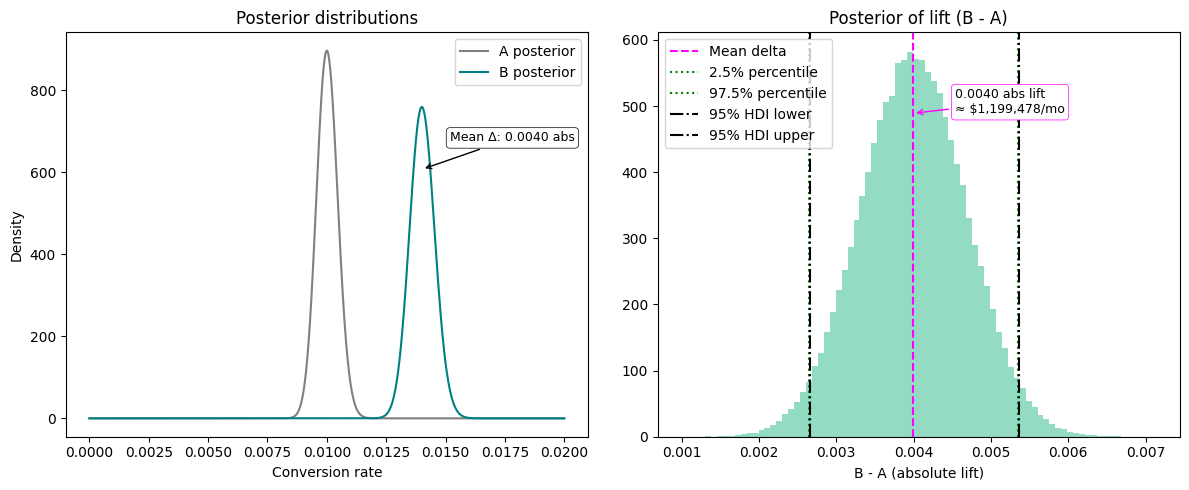

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import arviz as az

expected_revenue = mean_delta * monthly_impressions * average_purchase_value

# PDF plotting range
# Calculate PDFs for A and B posteriors
# computes the probability density function (PDF) values of group A's posterior
# Beta distribution at each point in x.
# The PDF tells you how likely each conversion rate value is under the posterior.
# creates an array of 1000 points evenly spaced from 0 up to a bit beyond the max
# observed conversion rate in either group (A or B).
# This x represents the range of conversion rates over which you'll evaluate the
# Beta distributions.
x = np.linspace(0, max(0.02, max(prob_samps_A.max(), prob_samps_B.max())*1.05), 1000)
pdf_A = beta.pdf(x, post_A_alpha, post_A_beta)
pdf_B = beta.pdf(x, post_B_alpha, post_B_beta)

# Plotting
plt.figure(figsize=(12, 5))

# First subplot: Posterior distributions
# Initialize plot
plt.subplot(1, 2, 1)
plt.plot(x, pdf_A, label="A posterior", color="grey")
plt.plot(x, pdf_B, label="B posterior", color="teal")

# Annotate mean delta
plt.annotate(f"Mean Δ: {mean_delta:.4f} abs",
             xy=(prob_samps_A.mean() + mean_delta, max(pdf_B)*0.8),
             xycoords='data',
             xytext=(20, 20),
             textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='black'),
             fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5))

plt.xlabel("Conversion rate")
plt.ylabel("Density")
plt.title("Posterior distributions")
plt.legend()

# Second subplot: Posterior lift histogram
# Initialize plot
plt.subplot(1, 2, 2)
# Histogram
plt.hist(delta_samples, bins=80, density=True, alpha=0.7, color='mediumaquamarine')
# Mean Delta
plt.axvline(mean_delta, color='magenta', linestyle="--", label="Mean delta")
# 95% Credible Interval
plt.axvline(ci_lower, color='green', linestyle=":", label="2.5% percentile")
plt.axvline(ci_upper, color='green', linestyle=":", label="97.5% percentile")
# 95% High Density Interval
plt.axvline(hdi_lower, color='black', linestyle="-.", label="95% HDI lower")
plt.axvline(hdi_upper, color='black', linestyle="-.", label="95% HDI upper")

# Annotate absolute lift + expected revenue gain
plt.annotate(f"{mean_delta:.4f} abs lift\n≈ ${expected_revenue:,.0f}/mo",
             xy=(mean_delta, plt.ylim()[1]*0.8),
             xycoords='data',
             xytext=(30, 0),
             textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='magenta'),
             fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="magenta", lw=0.5))

plt.xlabel("B - A (absolute lift)")
plt.title("Posterior of lift (B - A)")
plt.legend()

plt.tight_layout()
plt.show()


# Results Summary

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results%20Summary.png)

Additional events and revenue from B vs. A:

In [79]:
# Recommendation
print("Recommended decision:", decision)
print("")
print("Monthly_impressions:", monthly_impressions)
print("")
# Range of gain
print(f"Monthly incremental purchases: {conversion_diff_low:.0f} - {conversion_diff_high:.0f}")
print(f"Monthly incremental revenue: $ {total_revenue_diff_low:.0f} - ${total_revenue_diff_high:.0f}")
print("")
# Mean of gain
print(f"Mean monthly incremental purchases: {mean_conversion_diff:.0f}")
print(f"Mean monthly incremental revenue: ${mean_revenue_diff:.0f}")


Recommended decision: Declare B the winner

Monthly_impressions: 100000

Monthly incremental purchases: 267 - 537
Monthly incremental revenue: $ 799777 - $1609698

Mean monthly incremental purchases: 400
Mean monthly incremental revenue: $1199478
